In [69]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd

In [70]:
def weight_by_latitude(da):
    """Weight data array by cosine of latitude."""
    weights = np.cos(np.deg2rad(da['lat']))
    weighted_da = da * weights
    return weighted_da


def reshape_to_2d(da):
    """Reshape (lat, lon, time) data into 2D matrix (space x time)."""
    space_dim = da['lat'].size * da['lon'].size
    reshaped = da.stack(space=('lat', 'lon')).transpose('time', 'space')
    return reshaped


def compute_covariance_matrix(reshaped_da):
    """Compute the covariance matrix of the data."""
    data = reshaped_da.values
    data = data - np.nanmean(data, axis=0)  # Centering the data
    covariance_matrix = np.cov(data.T)
    return covariance_matrix


def perform_svd(cov_matrix):
    """Perform SVD on the covariance matrix."""
    U, S, Vt = np.linalg.svd(cov_matrix)
    return U, S, Vt


def plot_first_principal_component(reshaped_da, Vt):
    """Plot the first principal component as a map."""
    first_pc = Vt[0, :] #first eigenvector with largest eigenvalue
    pc_map = reshaped_da.isel(time=0).copy() #.isel selects the i you give, make a copy of given array at i
    pc_map.values = first_pc #change the values from before to the first_pc values
    pc_map_unstacked = pc_map.unstack('space')

    plt.figure(figsize=(8, 5))
    pc_map_unstacked.plot(cmap='RdBu')
    plt.title("First Principal Component (Spatial Pattern)")
    plt.show()

    return pc_map_unstacked


def compute_zonal_mean(pc_map_unstacked):
    """Compute the zonal mean of the first principal component map."""
    zonal_mean = pc_map_unstacked.mean(dim='lon')
    return zonal_mean


def make_zonal_mean_map(zonal_mean, da):
    """Create a zonal mean map, assigning each longitude the same value."""
    zonal_map = xr.zeros_like(da.isel(time=0)) #blank map with same dimensions as da
    for lon in zonal_map['lon']:
        zonal_map.loc[{'lon': lon}] = zonal_mean #assign zonal mean value to each longitude
    return zonal_map


def regress_onto_zonal_mean_map(da, zonal_map):
    """Regress original data onto the zonal mean map (time series of coefficients)."""
#flattening data
    zonal_map_flat = zonal_map.stack(space=('lat', 'lon')).values
    data_flat = da.stack(space=('lat', 'lon')).transpose('time', 'space').values
#detrending by removing mean
    zonal_map_flat = zonal_map_flat - np.nanmean(zonal_map_flat)
    data_flat = data_flat - np.nanmean(data_flat, axis=0)

    regression_coefficients = np.dot(data_flat, zonal_map_flat) / np.dot(zonal_map_flat, zonal_map_flat)

    return regression_coefficients


def plot_regression_coefficients(time, regression_coefficients):
    """Plot regression coefficients over time."""
    plt.figure(figsize=(8, 5))
    plt.plot(time, regression_coefficients, label='Regression Coefficients')
    plt.xlabel('Time')
    plt.ylabel('Coefficient')
    plt.title('Regression Coefficients Over Time')
    plt.grid()
    plt.show()
    
def extract_seasonal_data(array, seasons):
    """
    Extract data from the array for specific seasons (months).
    - A subset of the original array with only the data for the specified months.
    """
    # Make sure the 'time' dimension has a 'month' coordinate
    if 'time' in array.coords:
        # Extract month from the 'time' dimension
        months = array['time'].dt.month
        
        # Filter based on the provided seasons (months)
        seasonal_data = array.sel(time=months.isin(seasons))
        
        return seasonal_data
    else:
        raise ValueError("The input array does not contain a 'time' dimension.")
        
def compute_anomaly(array):
    anomaly=array.groupby('time.month')-array.groupby('time.month').mean('time')
    return(anomaly)

def shift_december(da):
    time_df = pd.to_datetime(da['time'])
    # Create a boolean mask for times in December
    time_series=pd.Series(time_df)
    mask = time_series.dt.month == 12
    time_series.loc[mask] = time_series.loc[mask] + pd.DateOffset(years=1)
    # Convert to numpy datetime64[D]
    time_df_upd = time_series.values.astype('datetime64[D]')
    #display(time_df_upd)
    d={'time':time_df_upd}
    da_new=da.assign_coords(d)
    return da_new

def seasonal_average(da):
    da2=da.groupby('time.year').mean('time')
    return(da2)

def stdize_ssavg(da):
    da2=(da-da.mean())/da.std()
    return da2

In [71]:
u=xr.open_dataset('data/era5_ua_2.5x2.5.nc')
u

<xarray.Dataset> Size: 33MB
Dimensions:         (valid_time: 1021, lon: 144, lat: 28, pressure_level: 2)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 8kB 1940-01-01 ... 2025-01-01
  * lon             (lon) float64 1kB 0.0 2.5 5.0 7.5 ... 352.5 355.0 357.5
  * lat             (lat) float64 224B -86.79 -80.36 -73.93 ... 80.36 86.79
  * pressure_level  (pressure_level) float64 16B 850.0 50.0
Data variables:
    u               (valid_time, pressure_level, lat, lon) float32 33MB ...
Attributes:
    CDI:                     Climate Data Interface version 2.5.0 (https://mp...
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    history:                 Fri Feb 14 12:09:57 2025: cdo remapbil,r144x28 e...
    CDO:                     Climate Data Operators version 2.5.0 (https://mp...

In [72]:
## select u50
u50=u.sel(pressure_level=50).rename({'valid_time':'time'}).drop('pressure_level')
# select time period and latitude
u50=u50.sel(time=slice('1950','2025'))

/tmp/ipykernel_80981/1548602930.py:2: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  u50=u.sel(pressure_level=50).rename({'valid_time':'time'}).drop('pressure_level')


In [73]:
#zonal mean
u_zonal = u50.mean(dim="lon")
#interpolate values to -60°S
u_60S = u_zonal.interp(lat=-60)
#rolling window
u_60_roll=u_60S.rolling(time=5, center=True).mean()

#find breakdown date
def find_breakdown_date(u_series):
    """
    u_series: 1D DataArray (time for one year)
    returns: datetime or NaT
    """
    condition = u_series < 10  # threshold

    if condition.any():
        return u_series.time.where(condition, drop=True)[-1].values
    else:
        return np.datetime64("NaT")

##do this for each year
years = np.unique(u_60_roll["time.year"])

breakdown_dates = []

for year in years:
    u_year = u_60_roll.sel(time=str(year))['u']

    date = find_breakdown_date(u_year)
    breakdown_dates.append(date)

breakdown_dates = xr.DataArray(
    breakdown_dates,
    coords={"year": years},
    dims=["year"],
    name="vortex_breakdown_date"
)

<xarray.DataArray 'vortex_breakdown_date' (year: 76)> Size: 608B
array([                          'NaT', '1951-12-01T00:00:00.000000000',
       '1952-02-01T00:00:00.000000000',                           'NaT',
       '1954-02-01T00:00:00.000000000', '1955-02-01T00:00:00.000000000',
       '1956-02-01T00:00:00.000000000', '1957-12-01T00:00:00.000000000',
       '1958-02-01T00:00:00.000000000', '1959-02-01T00:00:00.000000000',
       '1960-02-01T00:00:00.000000000', '1961-02-01T00:00:00.000000000',
       '1962-02-01T00:00:00.000000000', '1963-02-01T00:00:00.000000000',
       '1964-12-01T00:00:00.000000000', '1965-02-01T00:00:00.000000000',
       '1966-02-01T00:00:00.000000000', '1967-12-01T00:00:00.000000000',
       '1968-12-01T00:00:00.000000000', '1969-02-01T00:00:00.000000000',
       '1970-02-01T00:00:00.000000000', '1971-02-01T00:00:00.000000000',
       '1972-02-01T00:00:00.000000000', '1973-02-01T00:00:00.000000000',
       '1974-02-01T00:00:00.000000000', '1975-02-01T00:00:00.000000000',
       '1976-02-01T00:00:00.000000000', '1977-02-01T00:00:00.000000000',
       '1978-02-01T00:00:00.000000000', '1979-02-01T00:00:00.000000000',
       '1980-02-01T00:00:00.000000000', '1981-02-01T00:00:00.000000000',
                                 'NaT', '1983-02-01T00:00:00.000000000',
       '1984-02-01T00:00:00.000000000', '1985-02-01T00:00:00.000000000',
       '1986-02-01T00:00:00.000000000', '1987-02-01T00:00:00.000000000',
       '1988-02-01T00:00:00.000000000', '1989-02-01T00:00:00.000000000',
       '1990-02-01T00:00:00.000000000', '1991-02-01T00:00:00.000000000',
       '1992-02-01T00:00:00.000000000', '1993-02-01T00:00:00.000000000',
       '1994-02-01T00:00:00.000000000', '1995-02-01T00:00:00.000000000',
                                 'NaT', '1997-02-01T00:00:00.000000000',
       '1998-02-01T00:00:00.000000000',                           'NaT',
                                 'NaT', '2001-02-01T00:00:00.000000000',
       '2002-12-01T00:00:00.000000000', '2003-02-01T00:00:00.000000000',
       '2004-02-01T00:00:00.000000000', '2005-02-01T00:00:00.000000000',
       '2006-02-01T00:00:00.000000000', '2007-02-01T00:00:00.000000000',
                                 'NaT',                           'NaT',
       '2010-02-01T00:00:00.000000000',                           'NaT',
       '2012-12-01T00:00:00.000000000', '2013-02-01T00:00:00.000000000',
       '2014-02-01T00:00:00.000000000',                           'NaT',
                                 'NaT', '2017-02-01T00:00:00.000000000',
       '2018-02-01T00:00:00.000000000', '2019-12-01T00:00:00.000000000',
       '2020-02-01T00:00:00.000000000',                           'NaT',
                                 'NaT',                           'NaT',
                                 'NaT',                           'NaT'],
      dtype='datetime64[ns]')
Coordinates:
  * year     (year) int64 608B 1950 1951 1952 1953 1954 ... 2022 2023 2024 2025

<xarray.DataArray 'dayofyear' ()> Size: 8B
array(60)


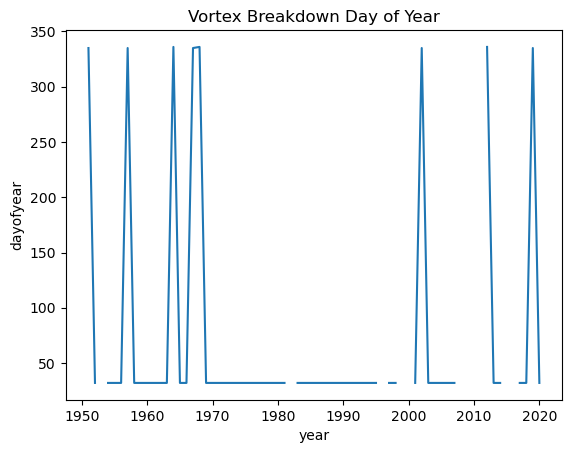

In [74]:
display(breakdown_dates)

##convert these into day of the year/Julian day
breakdown_doy = breakdown_dates.dt.dayofyear
breakdown_doy.plot()
plt.title('Vortex Breakdown Day of Year')
#print((breakdown_doy))
print(sum((~np.isnan(breakdown_doy))))

<xarray.DataArray ()> Size: 8B
array(60)


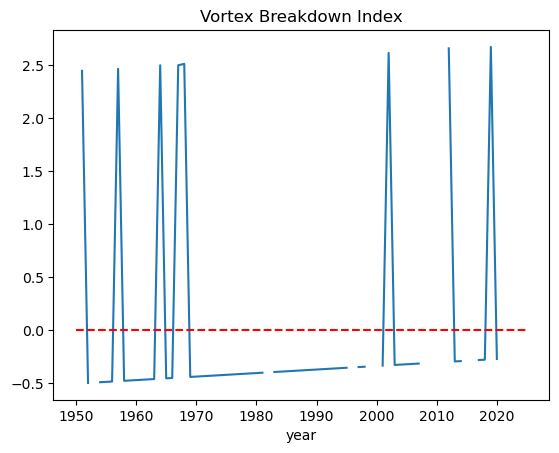

In [75]:
#detrend
p_vortex=breakdown_doy.polyfit(dim='year', deg=1, skipna=True)
#print(p_vortex)
vortex_fit=xr.polyval(breakdown_doy['year'], p_vortex.polyfit_coefficients)
vortex_detr=breakdown_doy-vortex_fit

#normalise
VB_index=vortex_detr/vortex_detr.std(dim='year')
print(sum(~np.isnan(VB_index)))
VB_index.plot()
plt.hlines(VB_index.mean(), VB_index.year.min(), VB_index.year.max(), colors='r', linestyles='dashed')
plt.title('Vortex Breakdown Index')
plt.show()

IOBW computation

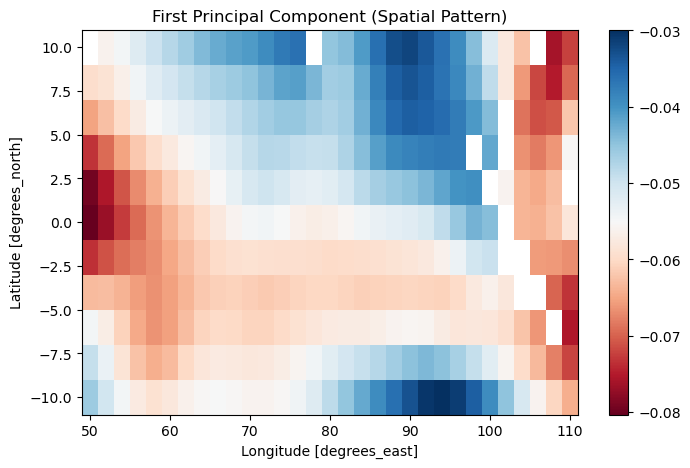

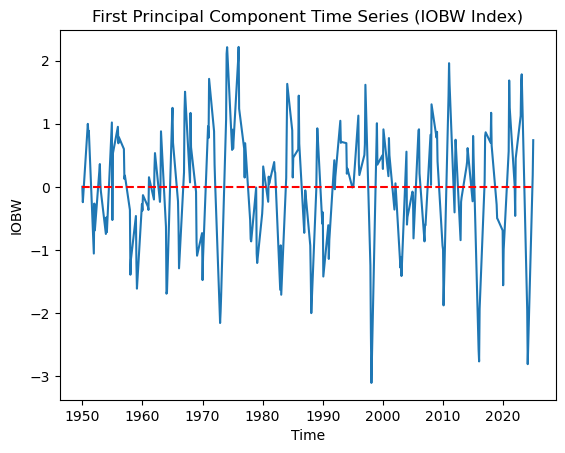

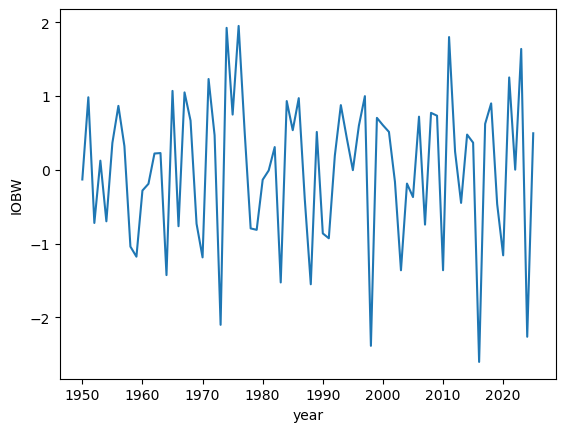

In [87]:
### Sea surface temperature, already monthly data
sst = xr.open_dataset('data/sst.mnmean.nc')
sst_io_whole=sst.sel(time=slice('1950','2025'),lat=slice(10,-10),lon=slice(50,110))

#1 seasonal data extraction
sst_DJF=extract_seasonal_data(sst_io_whole, seasons=[12, 1, 2])
#2 compute anomaly
sst_DJF_anom=compute_anomaly(sst_DJF)['sst']
#2b detrend
#detrend
p_sst=sst_DJF_anom.polyfit(dim='time', deg=1, skipna=True)
sst_fit=xr.polyval(sst_DJF_anom['time'], p_sst.polyfit_coefficients)
sst_detr=sst_DJF_anom-sst_fit
#print(sst_detr)

#3 compute PCs (including weight by latitude)
sst_DJF_anom_weighted=weight_by_latitude(sst_detr)


reshaped_sst_DJF=reshape_to_2d(sst_DJF_anom_weighted).dropna(dim='space', how='all') #drop any space points that are all NaN
#4 "SAM" proecedure applied here
#cov_matrix=compute_covariance_matrix(reshaped_sst_DJF) not necessary?
#display(cov_matrix)
U, S, Vt=perform_svd(reshaped_sst_DJF)
pc_map_unstacked=plot_first_principal_component(reshaped_sst_DJF, Vt)
EOF1 = Vt[0, :]
EOF1_map = xr.DataArray(
    EOF1,
    coords={"space": reshaped_sst_DJF.space},
    dims=["space"]
).unstack("space")

PC1 = U[:, 0] * S[0] #index before normalisation
PC1_ts = xr.DataArray(
    PC1,
    coords={"time": reshaped_sst_DJF.time},
    dims=["time"],
    name="IOBW"
)

PC1_ts = (PC1_ts - PC1_ts.mean()) / PC1_ts.std()
PC1_ts.plot()
plt.hlines(PC1_ts.mean(), PC1_ts.time.min(), PC1_ts.time.max(), colors='r', linestyles='dashed')
plt.title('First Principal Component Time Series (IOBW Index)')
plt.show()

#seasonal averages and standardise again
IOBW_ssavg_DJF=stdize_ssavg(seasonal_average(shift_december(PC1_ts)))

IOBW_ssavg_DJF.plot()

Prepping both new indices and adding them to old data ready DJF

In [90]:
#1 exclude years
cut_years=[1950,2003,2020,2025]

def exclude_years_xr(xr_obj, years):
    return xr_obj.sel(year=~xr_obj.year.isin(years))

IOBW_ssavg_DJF=exclude_years_xr(IOBW_ssavg_DJF, cut_years)
VB_index=exclude_years_xr(VB_index, cut_years)

#convert to dataframe for adding to rest of indices
IOBW_df=IOBW_ssavg_DJF.to_dataframe()
VB_df=VB_index.to_dataframe(name='VB')

display(IOBW_df, VB_df)


,IOBW
year,
1951,0.983971
1952,-0.720049
1953,0.124452
1954,-0.697499
1955,0.365075
...,...
2019,-0.463127
2021,1.252798
2022,0.002749


,VB
year,
1951,2.444181
1952,-0.496852
1953,NaN
1954,-0.490213
1955,-0.486894
...,...
2019,2.669899
2021,NaN
2022,NaN


In [93]:
era_DJF_LaPlata_df=pd.read_csv('data_ready/6.csv',index_col='Unnamed: 0')
era_DJF_Andes_df=pd.read_csv('data_ready/4.csv',index_col='Unnamed: 0')

df1=pd.concat([era_DJF_LaPlata_df, IOBW_df, VB_df], axis=1)
df2=pd.concat([era_DJF_Andes_df, IOBW_df, VB_df], axis=1)

df1.to_csv('data_ready/6_with_IOBW_VB.csv')
df2.to_csv('data_ready/4_with_IOBW_VB.csv')